# Crop Clustering Analysis



This notebook performs K-Means clustering on crop soil data to:
- Identify natural groupings of soil conditions
- Analyze cluster centroids
- Study crop proportions within clusters
- Develop a distance-weighted crop recommendation system

## Import Required libraries 

In [1]:
## Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    silhouette_score,
    confusion_matrix,
    accuracy_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.spatial.distance import euclidean

## Load Dataset

In [103]:
df = pd.read_csv("C:/JUPYTERPROJECTS/Crop_Advisory_system/data/Crop_recommendation.csv")
df.head()



,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [104]:
## Feature Selection

X = df.drop("label", axis=1)
y = df["label"]

In [105]:
X

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


## Feature Scaling

In [106]:
## Feature Scaling

# scaler = MinMaxScaler(feature_range=(1, 10))
# X_scaled = scaler.fit_transform(X)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [107]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    
    print(f"K={k}, Silhouette Score={round(score,4)}")

K=2, Silhouette Score=0.3247
K=3, Silhouette Score=0.1941
K=4, Silhouette Score=0.2553
K=5, Silhouette Score=0.2596
K=6, Silhouette Score=0.313
K=7, Silhouette Score=0.3333
K=8, Silhouette Score=0.3311
K=9, Silhouette Score=0.3412
K=10, Silhouette Score=0.3426
K=11, Silhouette Score=0.3435
K=12, Silhouette Score=0.339
K=13, Silhouette Score=0.3335
K=14, Silhouette Score=0.34


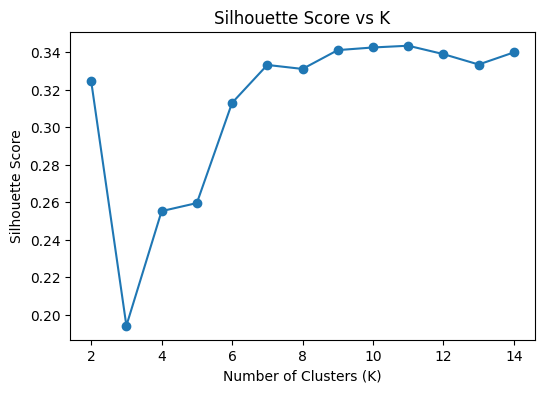

In [108]:
plt.figure(figsize=(6,4))
plt.plot(range(2,15), sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

In [109]:
best_k = range(2,15)[np.argmax(sil_scores)]
print("Best K:", best_k)

Best K: 11


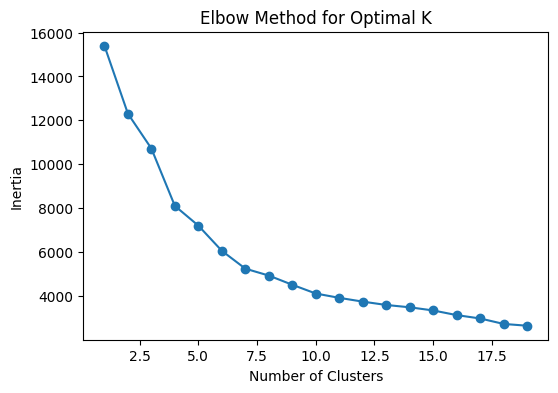

In [110]:
## Elbow Method

inertia = []

for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,20), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


The elbow appears around k = 10. Therefore, we select 10 clusters.

## Applying KMeans (k=10)

In [111]:
## Apply KMeans

kmeans = KMeans(n_clusters=11, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label,Cluster
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,8
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,8
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,8
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,8
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,8


## Silhouette Score


In [112]:
score = silhouette_score(X_scaled, df["Cluster"])
print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.3435


## PCA Visualization of Clusters

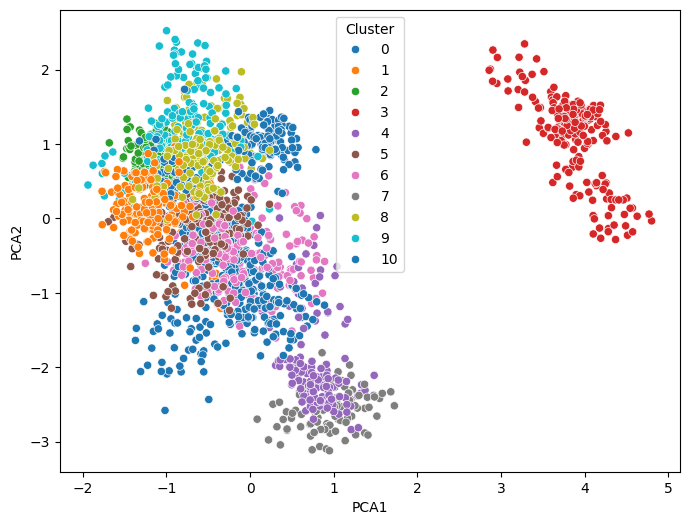

In [113]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="tab10")
plt.show()

## Number of Samples in Each Cluster

In [114]:


df["Cluster"].value_counts().sort_index()


Cluster
0     396
1     173
2     201
3     200
4     140
5     176
6     185
7      95
8     215
9     185
10    234
Name: count, dtype: int64

## Number of Unique Crops in Each Cluster

In [115]:

df.groupby("Cluster")["label"].nunique()


Cluster
0     9
1     4
2     3
3     2
4     4
5     3
6     3
7     1
8     5
9     4
10    6
Name: label, dtype: int64

## Cluster vs Crop Distribution Table

In [116]:
## Cluster vs Crop Distribution Table

cluster_crop_table = pd.crosstab(df["Cluster"], df["label"])

cluster_crop_table


label,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,100,0,0,0,0,0,0,0,...,11,58,100,0,2,18,10,0,0,0
1,0,0,0,0,0,89,55,0,10,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,100,0,0,0,0,0,100
3,100,0,0,0,0,0,0,100,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,5,0,0,0,0,0,100,...,0,0,0,0,0,0,32,0,0,0
5,0,0,0,0,5,0,0,0,0,0,...,0,0,0,0,71,0,0,100,0,0
6,0,0,0,0,0,0,0,0,0,0,...,89,42,0,0,0,0,54,0,0,0
7,0,0,0,95,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,11,0,0,89,0,...,0,0,0,0,0,14,1,0,100,0


## Show Crops Present in Each Cluster

In [117]:


for i in range(10):
    crops_in_cluster = df[df["Cluster"] == i]["label"].unique()
    print(f"\nCluster {i} contains {len(crops_in_cluster)} crops:")
    print(crops_in_cluster)



Cluster 0 contains 9 crops:
['maize' 'pigeonpeas' 'mothbeans' 'mungbean' 'blackgram' 'lentil' 'mango'
 'orange' 'papaya']

Cluster 1 contains 4 crops:
['maize' 'cotton' 'jute' 'coffee']

Cluster 2 contains 3 crops:
['watermelon' 'muskmelon' 'cotton']

Cluster 3 contains 2 crops:
['grapes' 'apple']

Cluster 4 contains 4 crops:
['chickpea' 'kidneybeans' 'pigeonpeas' 'lentil']

Cluster 5 contains 3 crops:
['pomegranate' 'orange' 'coconut']

Cluster 6 contains 3 crops:
['pigeonpeas' 'mothbeans' 'mango']

Cluster 7 contains 1 crops:
['chickpea']

Cluster 8 contains 5 crops:
['rice' 'pigeonpeas' 'papaya' 'jute' 'coffee']

Cluster 9 contains 4 crops:
['pigeonpeas' 'orange' 'papaya' 'coconut']


## Top 3 Clusters Based on Sample Size

In [118]:
# Top 3 clusters based on number of data points

cluster_counts = df['Cluster'].value_counts()

top3_clusters = cluster_counts.head(3).index.tolist()

print("Top 3 Clusters:")
print(cluster_counts.head(3))

Top 3 Clusters:
Cluster
0     396
10    234
8     215
Name: count, dtype: int64


In [119]:
# ## Train-Test Split

# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, y, test_size=0.2, random_state=42
# )

In [120]:
# ## Train KMeans on Train Data

# kmeans = KMeans(n_clusters=10, random_state=42)
# kmeans.fit(X_train)

In [121]:
# ## Predict Clusters

# test_clusters = kmeans.predict(X_test)

# test_df = pd.DataFrame({
#     "Actual Crop": y_test.values,
#     "Cluster": test_clusters
# })

In [122]:
# ## Cluster Mapping

# train_clusters = kmeans.labels_

# train_df = pd.DataFrame({
#     "Cluster": train_clusters,
#     "Crop": y_train.values
# })

# cluster_mapping = train_df.groupby("Cluster")["Crop"].agg(
#     lambda x: x.value_counts().index[0]
# )

# cluster_mapping

In [123]:
# ## Predict Crop

# test_df["Predicted Crop"] = test_df["Cluster"].map(cluster_mapping)

# # test_df.head()

In [124]:
# ## Accuracy

# accuracy = accuracy_score(test_df["Actual Crop"], test_df["Predicted Crop"])
# print("Clustering Accuracy:", round(accuracy, 4))

In [125]:
# ## Confusion Matrix

# cm = confusion_matrix(test_df["Actual Crop"], test_df["Predicted Crop"])

# plt.figure(figsize=(10,8))
# sns.heatmap(cm, cmap="Blues")
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

In [126]:
## ARI & NMI

ari = adjusted_rand_score(y_test, test_clusters)
nmi = normalized_mutual_info_score(y_test, test_clusters)

print("ARI:", round(ari, 4))
print("NMI:", round(nmi, 4))

ARI: 0.3893
NMI: 0.72


## Centroid Calculation

In [127]:
# Extract centroids

centroids = kmeans.cluster_centers_

top3_centroids = {c: centroids[c] for c in top3_clusters}

top3_centroids

{0: array([-0.6421427 ,  0.14023265, -0.5296244 ,  0.50208719, -0.10443636,
         0.84505273, -0.83524206]),
 10: array([ 1.18851915,  0.30609557, -0.28474213, -0.13420454,  0.18241248,
        -0.45752616, -0.22549055]),
 8: array([ 0.72111585, -0.19223111, -0.16176009, -0.23609831,  0.41765092,
         0.10322971,  1.87850477])}

Centroid represents the average soil condition of a cluster.

## Crop Proportions in Top 3 Clusters

In [128]:
# Calculate proportions of crops inside each top cluster

cluster_proportions = {}

for cluster in top3_clusters:
    cluster_data = df[df['Cluster'] == cluster]
    proportions = cluster_data['label'].value_counts(normalize=True)
    cluster_proportions[cluster] = proportions

cluster_proportions

{0: label
 blackgram     0.252525
 mungbean      0.252525
 lentil        0.242424
 mothbeans     0.146465
 papaya        0.045455
 mango         0.027778
 pigeonpeas    0.025253
 orange        0.005051
 maize         0.002525
 Name: proportion, dtype: float64,
 10: label
 banana    0.427350
 maize     0.341880
 cotton    0.188034
 papaya    0.034188
 lentil    0.004274
 jute      0.004274
 Name: proportion, dtype: float64,
 8: label
 rice          0.465116
 jute          0.413953
 papaya        0.065116
 coffee        0.051163
 pigeonpeas    0.004651
 Name: proportion, dtype: float64}

## Distance-Based Weighted Crop Scoring

Score = (1 / Distance) × P(category)

In [131]:
## Final Formula-Based Recommendation (Correct Weight Definition)

from scipy.spatial.distance import euclidean

# Step 1: Cluster sizes (counts, NOT normalized)
cluster_counts = df["Cluster"].value_counts()

# Step 2: Select Top 3 clusters
top_clusters = cluster_counts.head(3).index.tolist()

print("Top 3 Clusters:", top_clusters)

# Step 3: Compute total samples in top 3 clusters
total_top3_samples = cluster_counts[top_clusters].sum()

# Step 4: Prepare input
new_input = np.array([90, 42, 43, 20.8, 82.0, 6.5, 202.9])

new_df = pd.DataFrame([new_input], columns=X.columns)
new_scaled = scaler.transform(new_df)[0]

# Step 5: Compute scores
scores = {}

for cluster in top_clusters:
    
    centroid = centroids[cluster]
    distance = euclidean(new_scaled, centroid)
    
    # ✔ Correct weight (your formula)
    weight = cluster_counts[cluster] / total_top3_samples
    
    # ✔ Proportion
    cluster_data = df[df["Cluster"] == cluster]
    proportions = cluster_data["label"].value_counts(normalize=True)

    for crop, prop in proportions.items():
        
        score = (1 / (distance + 1e-6)) * prop * weight
        
        if crop not in scores:
            scores[crop] = 0
        scores[crop] += score

# Step 6: Sort
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

# Step 7: Display
result_df = pd.DataFrame(sorted_scores[:5], columns=["Crop", "Score"])
result_df

Top 3 Clusters: [0, 10, 8]


,Crop,Score
0,rice,0.144463
1,jute,0.129072
2,banana,0.049955
3,maize,0.040287
4,blackgram,0.032286


In [67]:
# # # Example new soil input
# new_input = np.array([50, 40, 30, 25, 70, 6.5, 100])

# # # IMPORTANT: Scale input
# # new_input_scaled = scaler.transform([new_input])[0]


# new_input_df = pd.DataFrame(
#     [new_input],
#     columns=X.columns
# )

# new_input_scaled = scaler.transform(new_input_df)[0]

# scores = {}

# for cluster in top3_clusters:
#     centroid = top3_centroids[cluster]
#     distance = euclidean(new_input_scaled, centroid)
    
#     proportions = cluster_proportions[cluster]
    
#     for crop, prop in proportions.items():
#         score = (1 / (distance + 1e-6)) * prop #to avoid division by zero
        
#         if crop not in scores:
#             scores[crop] = 0
        
#         scores[crop] += score

In [69]:
# sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

# print("Recommended Crops Ranked:")
# for crop, score in sorted_scores[:5]:
#     print(crop, score)

## Conclusion



- KMeans clustering grouped similar soil conditions into 10 clusters.
- The top 3 clusters were selected based on sample size to focus on dominant soil patterns.
- Centroids represent the average soil characteristics of each cluster.
- Crop proportions indicate dominant crops within each cluster.
- A distance-weighted scoring mechanism was implemented:

  Score = (1 / Distance) × P(category)

- This approach combines geometric similarity (Euclidean distance) and probabilistic dominance (crop proportion) to generate ranked crop recommendations.

This method transforms clustering results into an interpretable crop advisory system.